# Figure S4 Relationship between structural connection strength (number of touches) and participation in simplex motifs, across pruning types. 

#### Columns are pruning types, rows are species: human (teal), rat (purple). 

For each edge we take the maximal dimension
of a simplex it belongs to: 1 if it is isolated, 2 if it belongs to a 2-simplex but to no n-simplex with
n > 2, and so on. We analyze the subnetworks obtained by sliding a threshold on this value, calling
the subnetwork on edges of value n or higher the subnetwork at dimension n; at dimension 1 this
is the full network. Top plots show the average touch count over the edges of the subnetwork at
each dimension, with the standard error of the mean in the shaded region. Bottom plots show the
number of edges in the corresponding subnetworks. Connections with many touches aggregate in
higher-dimensional simplices, and this effect is more robust for the CPC networks than for the other
prunings. T-to-T pruning was omitted, as the density of those networks makes this computation
prohibitively expensive.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

ws_H_CPC = pd.read_csv("weighted_simplices_H_CPC.csv")
ws_H_TtoE = pd.read_csv("weighted_simplices_H_TtoE.csv")
ws_H_EtoE = pd.read_csv("weighted_simplices_H_EtoE.csv")
ws_H_EtoT = pd.read_csv("weighted_simplices_H_EtoT.csv")
#print(ws_H_CPC.head())  # inspect columns first

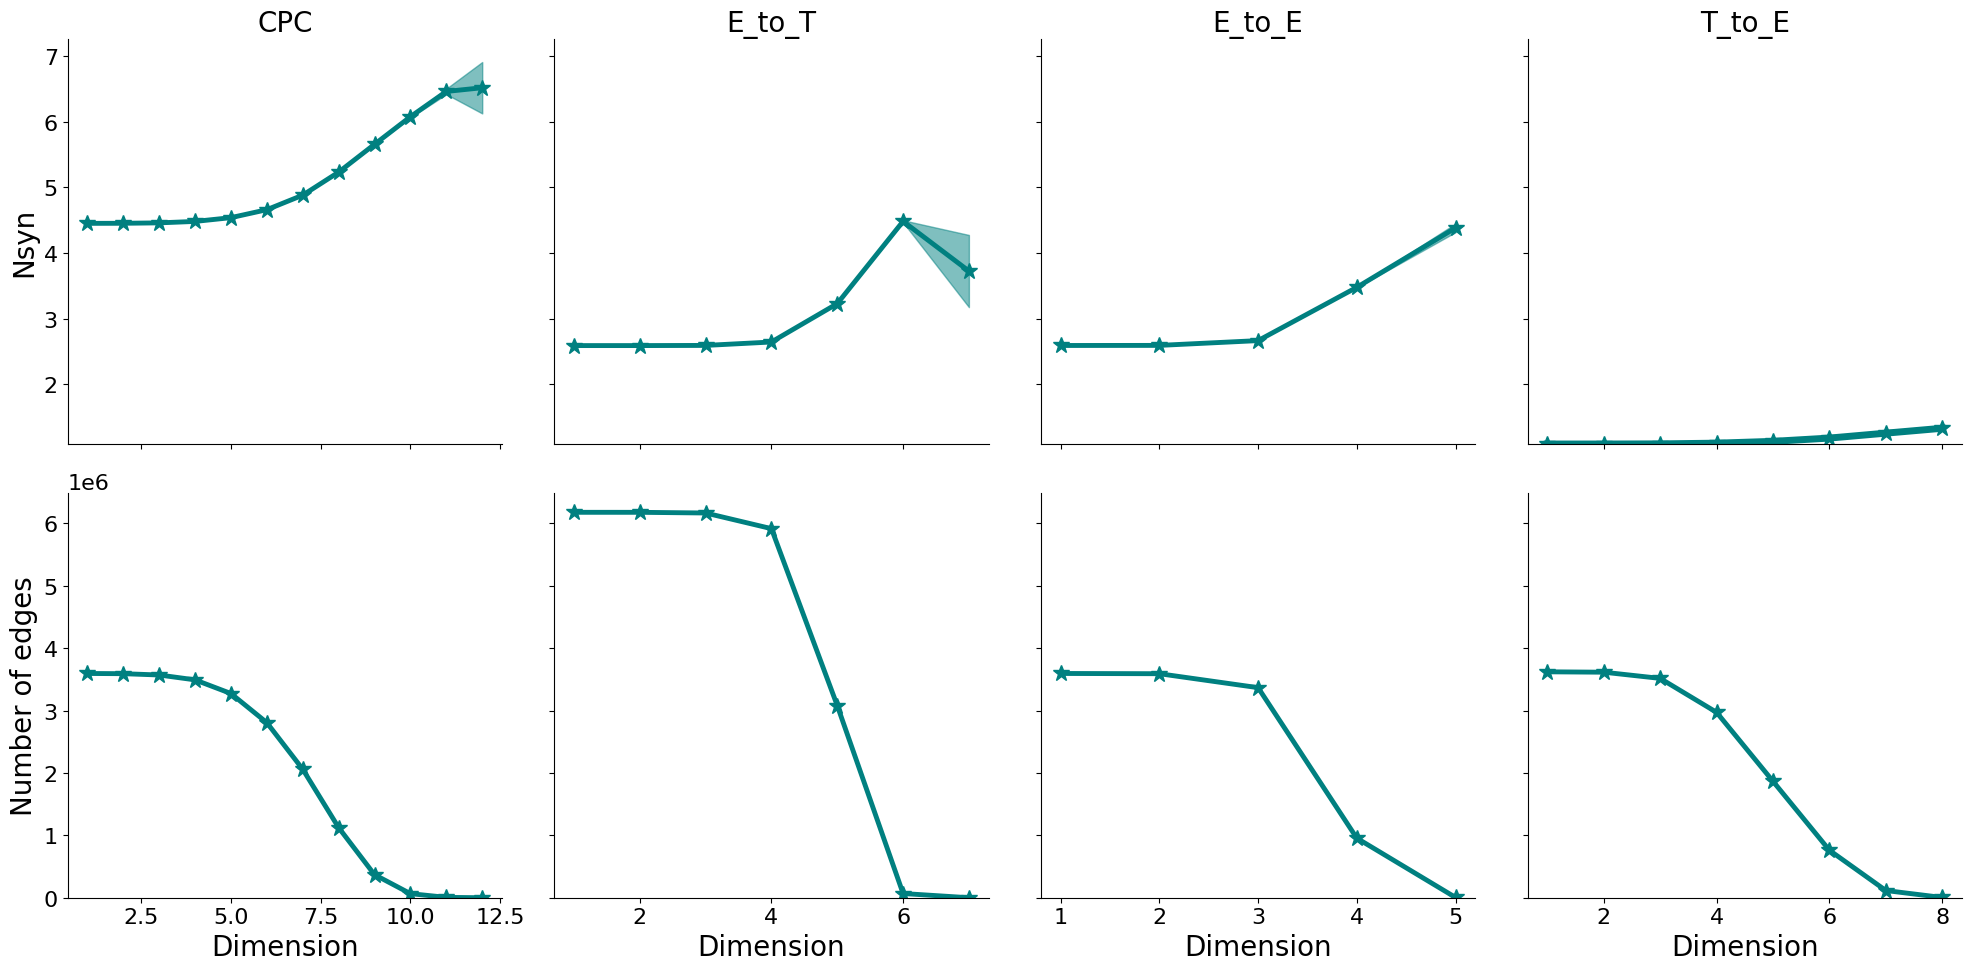

In [12]:
# =====================
# Global styling (fonts + line widths)
# =====================
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "lines.linewidth": 5
})

fig, axs = plt.subplots(
    2, 4,
    figsize=(20, 10),
    sharey='row',
    sharex='col'
)

# =====================
# CPC
# =====================
axs[0,0].plot(
    ws_H_CPC[1:].index,
    ws_H_CPC[1:].mean(axis=1),
    marker="*",
    markersize=12,
    color="teal",
    linewidth=3.5
)
axs[0,0].fill_between(
    ws_H_CPC[1:].index,
    ws_H_CPC[1:].mean(axis=1) + ws_H_CPC[1:].sem(axis=1),
    ws_H_CPC[1:].mean(axis=1) - ws_H_CPC[1:].sem(axis=1),
    color="teal",
    alpha=0.5
)
axs[0,0].set_title("CPC")

axs[1,0].plot(
    (~ws_H_CPC.isna()).sum(axis=1).drop(0),
    marker="*",
    markersize=12,
    color="teal",
    linewidth=3.5
)

# =====================
# E to T
# =====================
axs[0,1].plot(
    ws_H_EtoT[1:].index,
    ws_H_EtoT[1:].mean(axis=1),
    marker="*",
    markersize=12,
    color="teal",
    linewidth=3.5
)
axs[0,1].fill_between(
    ws_H_EtoT[1:].index,
    ws_H_EtoT[1:].mean(axis=1) + ws_H_EtoT[1:].sem(axis=1),
    ws_H_EtoT[1:].mean(axis=1) - ws_H_EtoT[1:].sem(axis=1),
    color="teal",
    alpha=0.5
)
axs[0,1].set_title("E_to_T")

axs[1,1].plot(
    (~ws_H_EtoT.isna()).sum(axis=1).drop(0),
    marker="*",
    markersize=12,
    color="teal",
    linewidth=3.5
)

# =====================
# E to E
# =====================
axs[0,2].plot(
    ws_H_EtoE[1:].index,
    ws_H_EtoE[1:].mean(axis=1),
    marker="*",
    markersize=12,
    color="teal",
    linewidth=3.5
)
axs[0,2].fill_between(
    ws_H_EtoE[1:].index,
    ws_H_EtoE[1:].mean(axis=1) + ws_H_EtoE[1:].sem(axis=1),
    ws_H_EtoE[1:].mean(axis=1) - ws_H_EtoE[1:].sem(axis=1),
    color="teal",
    alpha=0.5
)
axs[0,2].set_title("E_to_E")

axs[1,2].plot(
    (~ws_H_EtoE.isna()).sum(axis=1).drop(0),
    marker="*",
    markersize=12,
    color="teal",
    linewidth=3.5
)

# =====================
# T to E
# =====================
axs[0,3].plot(
    ws_H_TtoE[1:].index,
    ws_H_TtoE[1:].mean(axis=1),
    marker="*",
    markersize=12,
    color="teal",
    linewidth=5
)
axs[0,3].fill_between(
    ws_H_TtoE[1:].index,
    ws_H_TtoE[1:].mean(axis=1) + ws_H_TtoE[1:].sem(axis=1),
    ws_H_TtoE[1:].mean(axis=1) - ws_H_TtoE[1:].sem(axis=1),
    color="teal",
    alpha=0.5
)
axs[0,3].set_title("T_to_E")

axs[1,3].plot(
    (~ws_H_TtoE.isna()).sum(axis=1).drop(0),
    marker="*",
    markersize=12,
    color="teal",
    linewidth=3.5
)

# =====================
# Formatting
# =====================

for ax in axs.flatten():
    ax.spines[["top", "right"]].set_visible(False)

for ax in axs[1, :]:
    ax.set_xlabel("Dimension")

axs[0,0].set_ylabel("Nsyn")
axs[1,0].set_ylabel("Number of edges")

# =====================
# Common y-limits per row
# =====================
row0_min = min(
    (ws_H_CPC.mean(axis=1) + ws_H_CPC.sem(axis=1)).min(),
    (ws_H_EtoT.mean(axis=1) + ws_H_EtoT.sem(axis=1)).min(),
    (ws_H_EtoE.mean(axis=1) + ws_H_EtoE.sem(axis=1)).min(),
    (ws_H_TtoE.mean(axis=1) + ws_H_TtoE.sem(axis=1)).min()
)

row0_max = max(
    (ws_H_CPC.mean(axis=1) + ws_H_CPC.sem(axis=1)).max(),
    (ws_H_EtoT.mean(axis=1) + ws_H_EtoT.sem(axis=1)).max(),
    (ws_H_EtoE.mean(axis=1) + ws_H_EtoE.sem(axis=1)).max(),
    (ws_H_TtoE.mean(axis=1) + ws_H_TtoE.sem(axis=1)).max()
)

for ax in axs[0, :]:
    ax.set_ylim(row0_min, row0_max * 1.05)

row1_max = max(
    (~ws_H_CPC.isna()).sum(axis=1).max(),
    (~ws_H_EtoT.isna()).sum(axis=1).max(),
    (~ws_H_EtoE.isna()).sum(axis=1).max(),
    (~ws_H_TtoE.isna()).sum(axis=1).max()
)

for ax in axs[1, :]:
    ax.set_ylim(0, row1_max * 1.05)

plt.tight_layout()
#fig.savefig("weighted_simplices_Human_new.svg")
# plt.show()

In [6]:
ws_R_CPC = pd.read_csv("weighted_simplices_R_CPC.csv")
ws_R_TtoE = pd.read_csv("weighted_simplices_R_TtoE.csv")
ws_R_EtoE = pd.read_csv("weighted_simplices_R_EtoE.csv")
ws_R_EtoT = pd.read_csv("weighted_simplices_R_EtoT.csv")

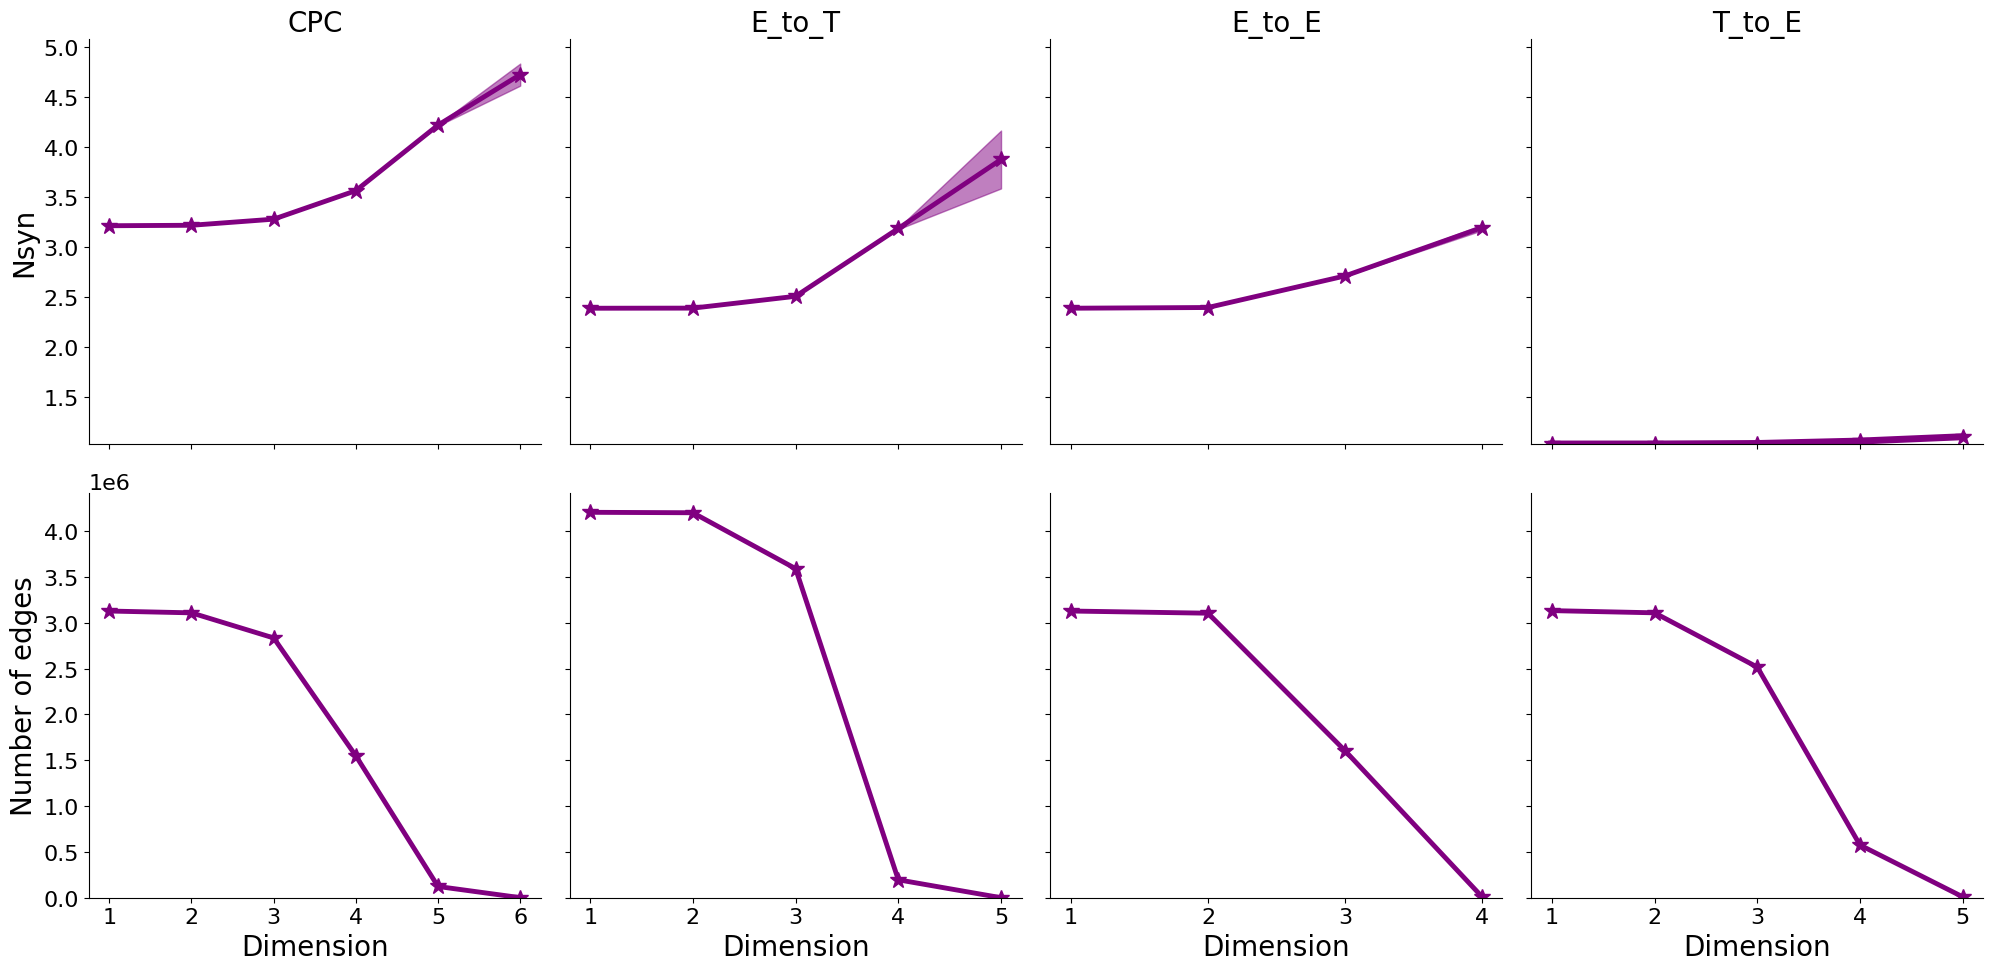

In [14]:
# =====================
# Global styling (fonts + line widths)
# =====================
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "lines.linewidth": 5
})

fig, axs = plt.subplots(
    2, 4,
    figsize=(20, 10),
    sharey='row',
    sharex='col'
)

# =====================
# CPC
# =====================
axs[0,0].plot(
    ws_R_CPC[1:].index,
    ws_R_CPC[1:].mean(axis=1),
    marker="*",
    markersize=12,
    color="purple",
    linewidth=3.5
)
axs[0,0].fill_between(
    ws_R_CPC[1:].index,
    ws_R_CPC[1:].mean(axis=1) + ws_R_CPC[1:].sem(axis=1),
    ws_R_CPC[1:].mean(axis=1) - ws_R_CPC[1:].sem(axis=1),
    color="purple",
    alpha=0.5
)
axs[0,0].set_title("CPC")

axs[1,0].plot(
    (~ws_R_CPC.isna()).sum(axis=1).drop(0),
    marker="*",
    markersize=12,
    color="purple",
    linewidth=3.5
)

# =====================
# E to T
# =====================
axs[0,1].plot(
    ws_R_EtoT[1:].index,
    ws_R_EtoT[1:].mean(axis=1),
    marker="*",
    markersize=12,
    color="purple",
    linewidth=3.5
)
axs[0,1].fill_between(
    ws_R_EtoT[1:].index,
    ws_R_EtoT[1:].mean(axis=1) + ws_R_EtoT[1:].sem(axis=1),
    ws_R_EtoT[1:].mean(axis=1) - ws_R_EtoT[1:].sem(axis=1),
    color="purple",
    alpha=0.5
)
axs[0,1].set_title("E_to_T")

axs[1,1].plot(
    (~ws_R_EtoT.isna()).sum(axis=1).drop(0),
    marker="*",
    markersize=12,
    color="purple",
    linewidth=3.5
)

# =====================
# E to E
# =====================
axs[0,2].plot(
    ws_R_EtoE[1:].index,
    ws_R_EtoE[1:].mean(axis=1),
    marker="*",
    markersize=12,
    color="purple",
    linewidth=3.5
)
axs[0,2].fill_between(
    ws_R_EtoE[1:].index,
    ws_R_EtoE[1:].mean(axis=1) + ws_R_EtoE[1:].sem(axis=1),
    ws_R_EtoE[1:].mean(axis=1) - ws_R_EtoE[1:].sem(axis=1),
    color="purple",
    alpha=0.5
)
axs[0,2].set_title("E_to_E")

axs[1,2].plot(
    (~ws_R_EtoE.isna()).sum(axis=1).drop(0),
    marker="*",
    markersize=12,
    color="purple",
    linewidth=3.5
)

# =====================
# T to E
# =====================
axs[0,3].plot(
    ws_R_TtoE[1:].index,
    ws_R_TtoE[1:].mean(axis=1),
    marker="*",
    markersize=12,
    color="purple",
    linewidth=5
)
axs[0,3].fill_between(
    ws_R_TtoE[1:].index,
    ws_R_TtoE[1:].mean(axis=1) + ws_R_TtoE[1:].sem(axis=1),
    ws_R_TtoE[1:].mean(axis=1) - ws_R_TtoE[1:].sem(axis=1),
    color="purple",
    alpha=0.5
)
axs[0,3].set_title("T_to_E")

axs[1,3].plot(
    (~ws_R_TtoE.isna()).sum(axis=1).drop(0),
    marker="*",
    markersize=12,
    color="purple",
    linewidth=3.5
)

# =====================
# Formatting
# =====================

for ax in axs.flatten():
    ax.spines[["top", "right"]].set_visible(False)

for ax in axs[1, :]:
    ax.set_xlabel("Dimension")

axs[0,0].set_ylabel("Nsyn")
axs[1,0].set_ylabel("Number of edges")

# =====================
# Common y-limits per row
# =====================
row0_min = min(
    (ws_R_CPC.mean(axis=1) + ws_R_CPC.sem(axis=1)).min(),
    (ws_R_EtoT.mean(axis=1) + ws_R_EtoT.sem(axis=1)).min(),
    (ws_R_EtoE.mean(axis=1) + ws_R_EtoE.sem(axis=1)).min(),
    (ws_R_TtoE.mean(axis=1) + ws_R_TtoE.sem(axis=1)).min()
)

row0_max = max(
    (ws_R_CPC.mean(axis=1) + ws_R_CPC.sem(axis=1)).max(),
    (ws_R_EtoT.mean(axis=1) + ws_R_EtoT.sem(axis=1)).max(),
    (ws_R_EtoE.mean(axis=1) + ws_R_EtoE.sem(axis=1)).max(),
    (ws_R_TtoE.mean(axis=1) + ws_R_TtoE.sem(axis=1)).max()
)

for ax in axs[0, :]:
    ax.set_ylim(row0_min, row0_max * 1.05)

row1_max = max(
    (~ws_R_CPC.isna()).sum(axis=1).max(),
    (~ws_R_EtoT.isna()).sum(axis=1).max(),
    (~ws_R_EtoE.isna()).sum(axis=1).max(),
    (~ws_R_TtoE.isna()).sum(axis=1).max()
)

for ax in axs[1, :]:
    ax.set_ylim(0, row1_max * 1.05)

plt.tight_layout()
#fig.savefig("weighted_simplices_Rat_new.svg")
# plt.show()